<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 24: Cluster Analysis & Geostatistics

**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences

This notebook explores the core concepts of Q-mode analysis (Cluster Analysis) and Geostatistics using simulated geological data.

**Prerequisites:** You will need the `pykrige` library for the geostatistics portion. You can install it by running `!pip install pykrige` in a code cell.

In [2]:
!pip install pykrige
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from pykrige.ok import OrdinaryKriging

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.6 MB/s eta 0:00:00


---
## Part 1: Q-Mode Analysis - Cluster Analysis

ysis is a method for organizing sampling units into groups, known as clusters, such that units within a particular cluster are more similar to each other than they are to units in different clusters. It is a Q-mode analysis used to classify sampling units into discrete groups.

### The Clustering Process
We focus on **hierarchical clustering**. The process follows these core steps:
1. **Dissimilarity Matrix:** The analysis begins with a matrix of "univariate dissimilarities" (such as Euclidean distance) between all pairs.
2. **Fusion of Most Similar Units:** The two units with the lowest dissimilarity are joined to form a cluster.
3. **Recalculation:** The dissimilarity matrix is updated. For this, we use a linkage method. The **group average linkage method** calculates the average of the dissimilarity measures between an outside unit and every individual unit within the new cluster.
4. **Iteration:** Merging continues until all units are joined.

Below, we simulate a geochemical dataset representing rock samples with varying concentrations of SiO2, Al2O3, and Fe2O3.

In [3]:
# Generate synthetic multivariate geochemical data (3 distinct rock types)
np.random.seed(42)

# Simulating Basalt, Andesite, and Rhyolite chemistries
basalt = np.random.normal(loc=[50, 15, 10], scale=[2, 1, 1], size=(15, 3))
andesite = np.random.normal(loc=[60, 16, 6], scale=[2, 1, 1], size=(15, 3))
rhyolite = np.random.normal(loc=[72, 13, 2], scale=[2, 1, 0.5], size=(15, 3))

# Combine into a single dataset
data = np.vstack((basalt, andesite, rhyolite))
true_labels = ['Basalt']*15 + ['Andesite']*15 + ['Rhyolite']*15
df = pd.DataFrame(data, columns=['SiO2', 'Al2O3', 'Fe2O3'])

df.head()

,SiO2,Al2O3,Fe2O3
0,50.993428,14.861736,10.647689
1,53.046060,14.765847,9.765863
2,53.158426,15.767435,9.530526
3,51.085120,14.536582,9.534270
4,50.483925,13.086720,8.275082


### The Dendrogram

The primary output of a hierarchical cluster analysis is a dendrogram, a tree-like diagram that illustrates the levels of similarity at which various units and clusters were joined. The y-axis represents the amount of dissimilarity allowed within clusters.

**Interpretation Cautions:** While the dendrogram creates distinct groups, these are often artificial divisions of continuous data. You must check if the statistical similarity aligns with known geological processes.

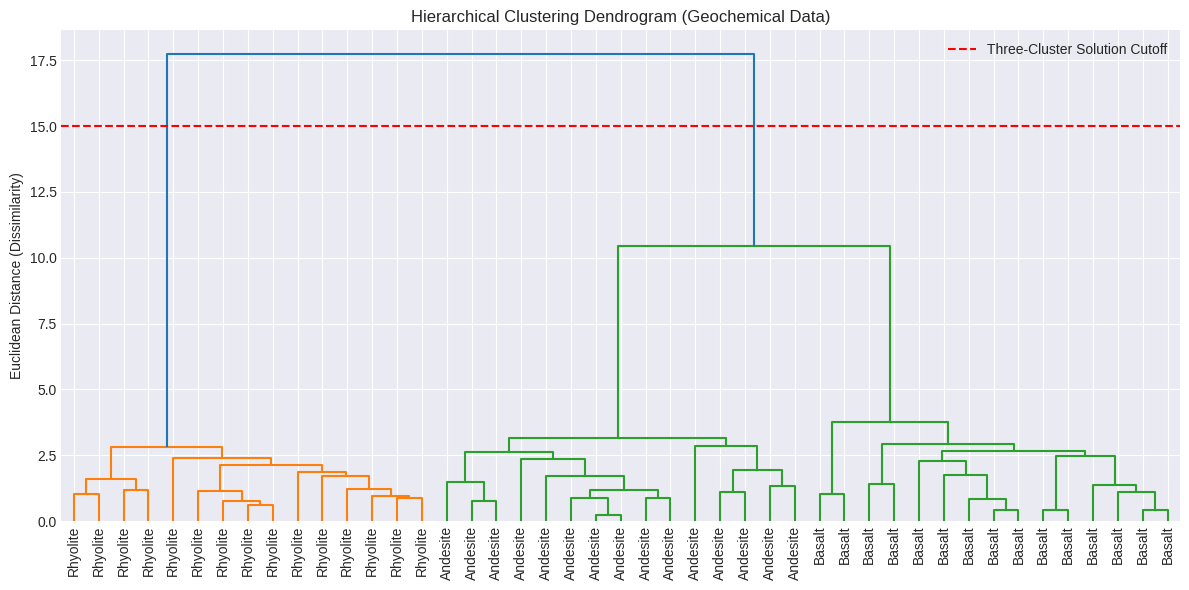

In [4]:
# Calculate the linkage matrix using the Group Average method and Euclidean distance
Z = linkage(df, method='average', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=true_labels, leaf_rotation=90, leaf_font_size=10, color_threshold=15)
plt.title('Hierarchical Clustering Dendrogram (Geochemical Data)')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.axhline(y=15, color='r', linestyle='--', label='Three-Cluster Solution Cutoff')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2: Geostatistics

Geostatistics operates on the premise that data points collected close to each other are more similar than those collected farther apart. This is the mathematical measurement of **Tobler’s First Law of Geography** (Spatial Autocorrelation).

Before predicting unknown values, we use **Exploratory Spatial Data Analysis (ESDA)**. The primary tool for this is the **Semivariogram**.

### The Anatomy of a Variogram
The variogram plots the variance between data points against the geographical distance separating them.
* **The Nugget ($c_0$):** The y-intercept, representing measurement error or micro-scale variations.
* **The Sill ($c_0 + c$):** The plateau where samples are no longer correlated (total variance).
* **The Range ($a$):** The distance where the variogram hits the sill.

Let's generate some spatial data (like drilling core samples for copper grade).

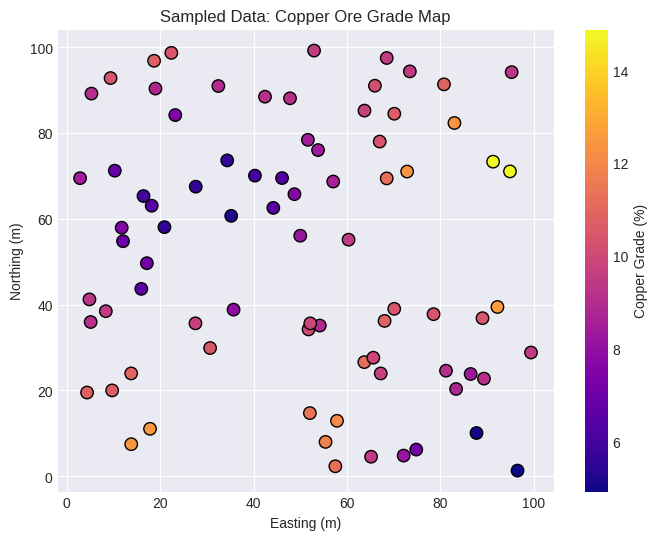

In [5]:
# Generate synthetic spatial data (X, Y coordinates and a regionalized variable Z)
np.random.seed(101)
x = np.random.uniform(0, 100, 80) # X coordinates (meters)
y = np.random.uniform(0, 100, 80) # Y coordinates (meters)

# Simulate a spatial pattern for Copper Grade (%) with some local noise (Nugget effect)
z = np.sin(x * 0.05) * np.cos(y * 0.05) * 5 + 10 + np.random.normal(0, 0.5, 80)

# Plot the raw spatial data
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x, y, c=z, cmap='plasma', s=80, edgecolors='k')
plt.colorbar(scatter, label='Copper Grade (%)')
plt.title('Sampled Data: Copper Ore Grade Map')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.show()

### Ordinary Kriging (Interpolation)

Kriging is the flagship interpolation method in geostatistics and is known as the **Best Linear Unbiased Estimator (BLUE)**.

We will use **Ordinary Kriging (OK)**, which assumes the local mean is constant but unknown, allowing the mean to fluctuate across the study area based on local data points.

We will fit an experimental variogram to a theoretical *Spherical* model. Kriging will then provide a predicted map, as well as a Kriging Variance map to show where our predictions are highly uncertain.

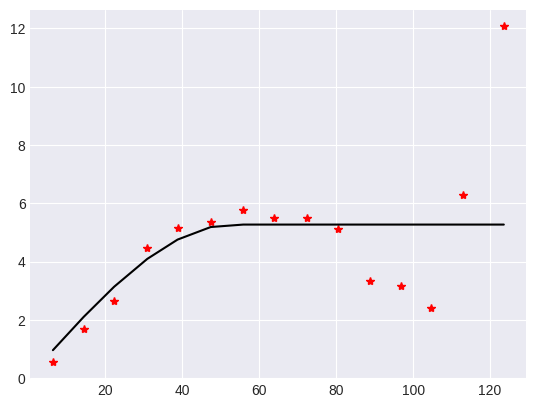

In [6]:
# Initialize Ordinary Kriging
# We use a theoretical Spherical model. enable_plotting=True will automatically generate the Variogram plot.
OK = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True, # Plots Experimental Variogram vs Theoretical Model
    nlags=15
)

# Create a dense grid to interpolate the continuous surface
gridx = np.arange(0.0, 100.0, 1.0)
gridy = np.arange(0.0, 100.0, 1.0)

# Execute Kriging interpolation
z_pred, z_var = OK.execute('grid', gridx, gridy)

### Visualizing the Kriging Results

The left map shows the optimal estimation (BLUE) of the copper grade across the entire grid. Because Kriging calculates optimal weights to prevent redundant clusters from dominating, it honors the spatial autocorrelation seamlessly.

The right map is the **Kriging Variance**. Notice how uncertainty is lowest exactly where our sample drillings (the white dots) are located, and highest in the blank spaces furthest from any data points.

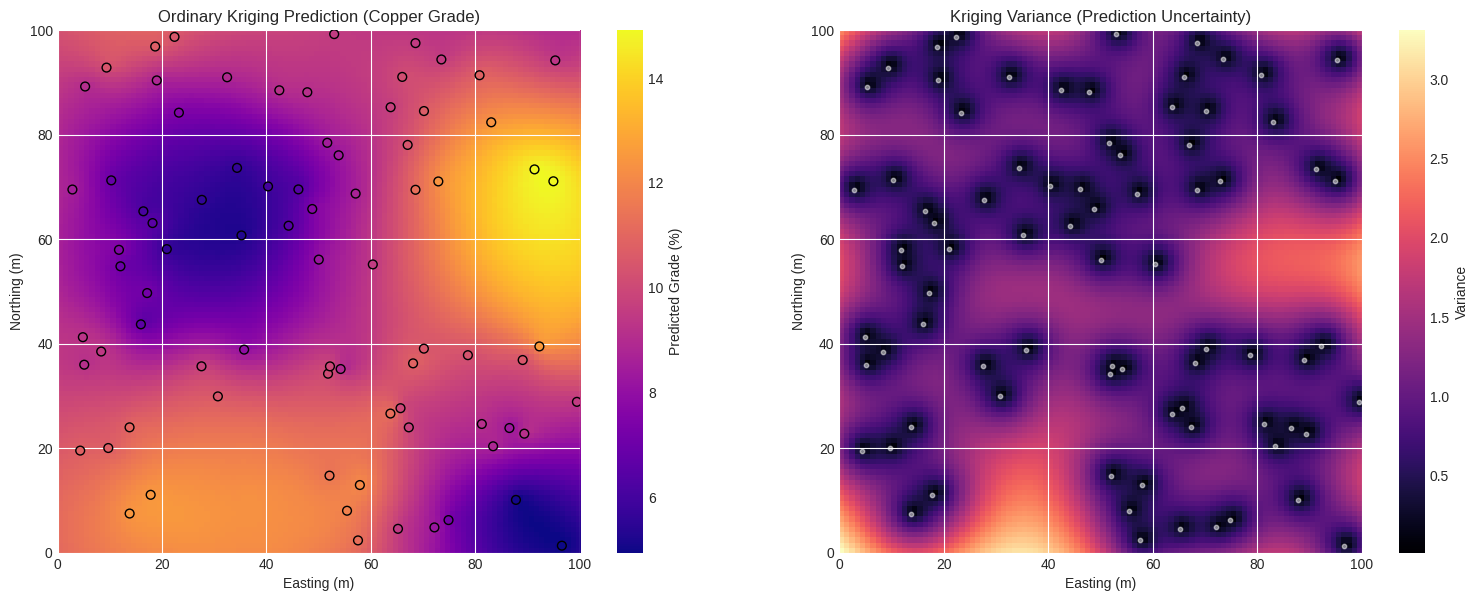

In [7]:
# Plot Kriging prediction and variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Predicted Map
c1 = ax1.imshow(z_pred, origin='lower', extent=(0, 100, 0, 100), cmap='plasma')
ax1.scatter(x, y, c=z, cmap='plasma', edgecolors='k', s=40) # Overlay original data
ax1.set_title('Ordinary Kriging Prediction (Copper Grade)')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
plt.colorbar(c1, ax=ax1, label='Predicted Grade (%)')

# Subplot 2: Variance (Uncertainty) Map
c2 = ax2.imshow(z_var, origin='lower', extent=(0, 100, 0, 100), cmap='magma')
ax2.scatter(x, y, c='white', marker='.', alpha=0.5, s=40) # Overlay sample locations
ax2.set_title('Kriging Variance (Prediction Uncertainty)')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
plt.colorbar(c2, ax=ax2, label='Variance')

plt.tight_layout()
plt.show()

---
## Part 3: Higher-Order Kriging

While Ordinary Kriging is the most widely used technique, specific datasets require more advanced Kriging models. Based on the lecture, we will look at two advanced methods:

### 1. Universal Kriging (UK) / Kriging with a Trend
Universal Kriging is used when there is a deterministic trend in the data (e.g., a regional slope, or temperature dropping as elevation increases). It separates the global trend from the local spatial autocorrelation, estimates them separately, and combines them for the final prediction.

### 2. Indicator Kriging (IK)
Indicator Kriging is used for categorical data (like soil types) or to assess the probability of a continuous variable exceeding a specific safety or economic threshold (e.g., the probability that soil lead levels exceed EPA limits).

Let's simulate a dataset with a strong regional trend (sloping upwards towards the East) and perform both Universal and Indicator Kriging.

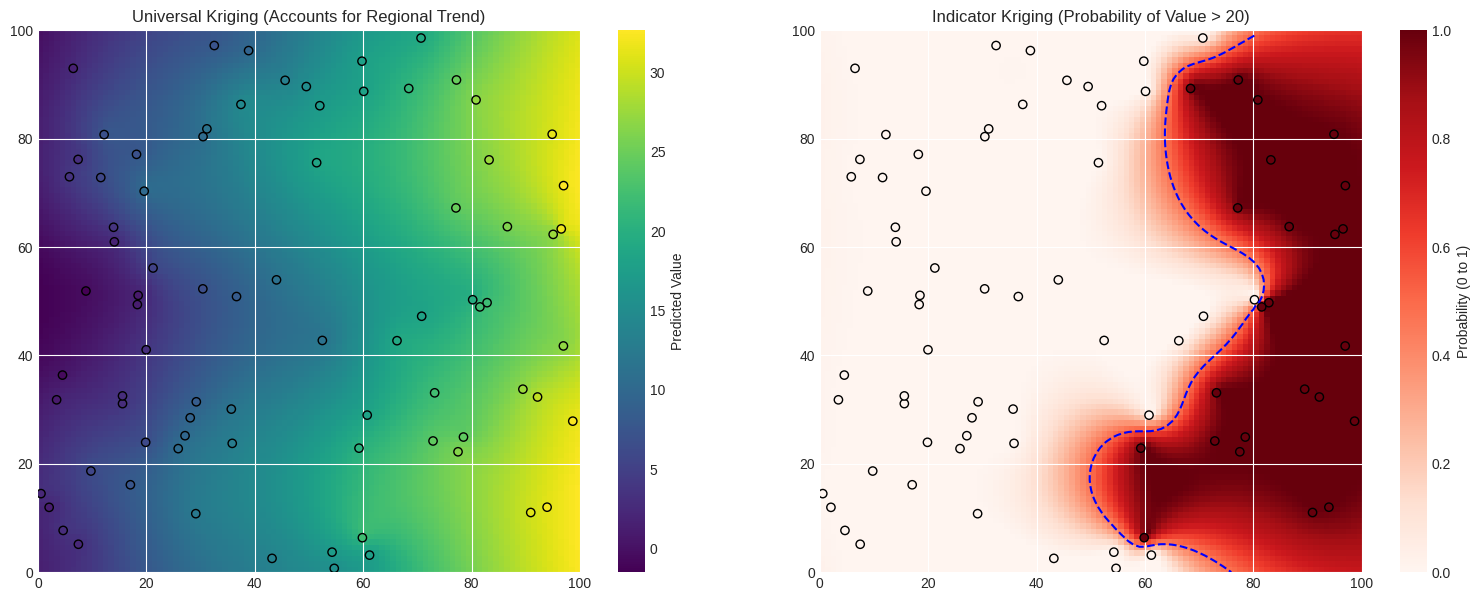

In [8]:
# Generate synthetic data with a strong East-West regional trend
np.random.seed(42)
x_trend = np.random.uniform(0, 100, 80)
y_trend = np.random.uniform(0, 100, 80)

# Regional trend (0.3 * x) plus some spatial noise
z_trend = (0.3 * x_trend) + np.sin(y_trend * 0.1) * 3 + np.random.normal(0, 1, 80)

# 1. UNIVERSAL KRIGING (UK)
from pykrige.uk import UniversalKriging

# We specify a 'linear' drift term to account for the regional trend
UK = UniversalKriging(
    x_trend, y_trend, z_trend,
    variogram_model='linear',
    drift_terms=['regional_linear']
)
z_pred_uk, z_var_uk = UK.execute('grid', gridx, gridy)

# 2. INDICATOR KRIGING (IK)
# We want to map the probability that the grade exceeds a threshold of 20
threshold = 20
z_indicator = np.where(z_trend > threshold, 1, 0) # Convert to 1s and 0s

# Ordinary Kriging applied to 0s and 1s acts as Indicator Kriging
IK = OrdinaryKriging(
    x_trend, y_trend, z_indicator,
    variogram_model='spherical',
    nlags=15
)
prob_ik, _ = IK.execute('grid', gridx, gridy)
# Constrain probabilities between 0 and 1
prob_ik = np.clip(prob_ik, 0, 1)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Universal Kriging Prediction
c1 = ax1.imshow(z_pred_uk, origin='lower', extent=(0, 100, 0, 100), cmap='viridis')
ax1.scatter(x_trend, y_trend, c=z_trend, cmap='viridis', edgecolors='k')
ax1.set_title('Universal Kriging (Accounts for Regional Trend)')
plt.colorbar(c1, ax=ax1, label='Predicted Value')

# Plot Indicator Kriging Probability Map
c2 = ax2.imshow(prob_ik, origin='lower', extent=(0, 100, 0, 100), cmap='Reds')
ax2.scatter(x_trend, y_trend, c=z_indicator, cmap='Reds', edgecolors='k')
ax2.contour(gridx, gridy, prob_ik, levels=[0.5], colors='blue', linestyles='dashed') # 50% probability line
ax2.set_title(f'Indicator Kriging (Probability of Value > {threshold})')
plt.colorbar(c2, ax=ax2, label='Probability (0 to 1)')

plt.tight_layout()
plt.show()

---
## Part 4: Geostatistical Simulation

Kriging provides the "best unbiased estimate", but it has a smoothing effect: it naturally underestimates high values and overestimates low values. If you need to preserve the true variance and texture of the data, you must use Geostatistical Simulation.

Simulations generate multiple, equally probable mathematical models (realizations) of the spatial distribution. By generating many realizations, geoscientists can quantify the uncertainty of an entire project.

### 1. Sequential Gaussian Simulation (SGS)
SGS is the most common method for continuous data. It generates stochastic (randomized) outcomes that honor the original data points, the overall histogram, and the variogram model. Every map looks different in the unsampled areas, but they perfectly match the known data at the drilled locations.

### 2. Sequential Indicator Simulation (SIS)
SIS is the categorical equivalent of SGS and builds directly on the math of Indicator Kriging. It simulates categorical data (like distinct rock types) without assuming an underlying parametric distribution like a bell curve. Instead of returning a specific value, it estimates the probability of each category existing, resulting in "patchy" or blocky maps that closely resemble natural geology.

Below, we will use the `gstools` library to perform two independent Conditional Sequential Gaussian Simulations. Notice how the two models differ in the "unknown" spaces while sharing the same statistical properties.

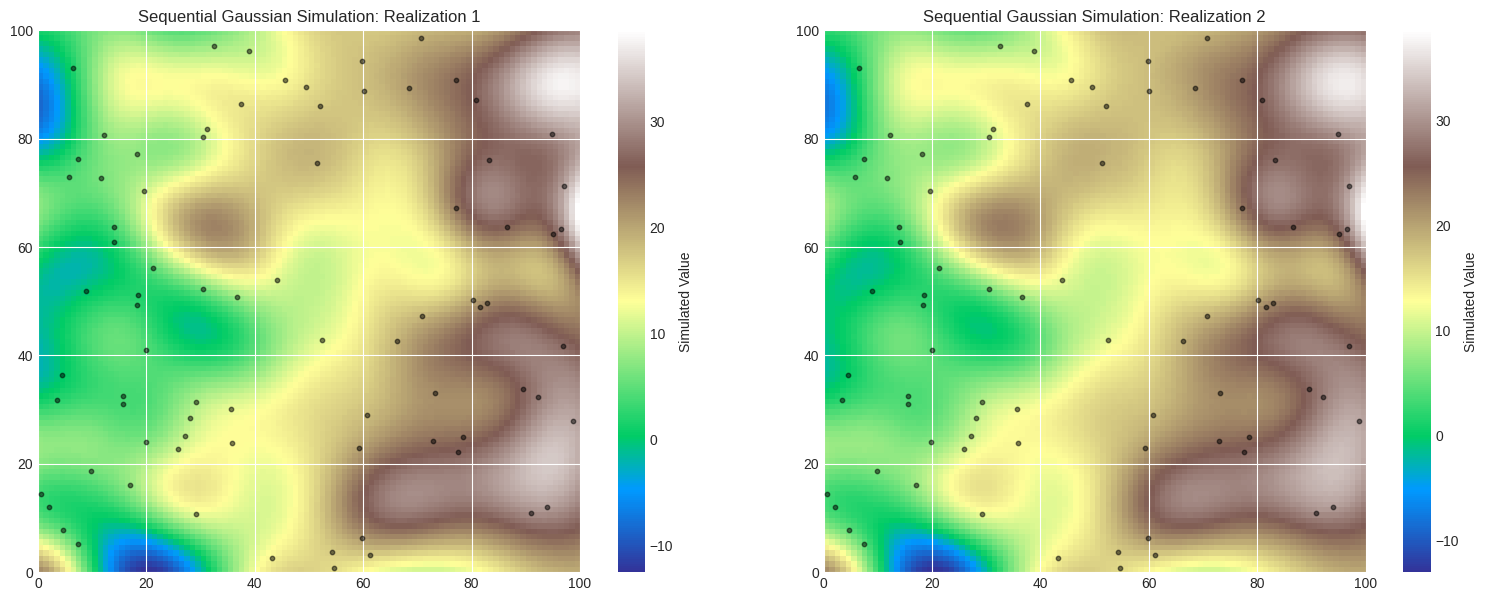

In [10]:
# !pip install gstools
import gstools as gs
import numpy as np
import matplotlib.pyplot as plt

# Define a theoretical spatial covariance model
# We'll use a Gaussian model with a variance of 2.0 and a spatial length scale of 15
model = gs.Gaussian(dim=2, var=2.0, len_scale=15)

# NEW API: Set up an Ordinary Kriging object with our conditioning data first
krig = gs.krige.Ordinary(model, cond_pos=(x_trend, y_trend), cond_val=z_trend)

# Setup the Conditional Spatial Random Field (Simulation) using the Kriging object
cond_srf = gs.CondSRF(krig)

# Generate Realization 1
# We pass the grid points and specify a structured mesh
cond_srf(pos=(gridx, gridy), mesh_type='structured', seed=101)
realization_1 = cond_srf.field

# Generate Realization 2 (using a different random seed to get a different probable outcome)
cond_srf(pos=(gridx, gridy), mesh_type='structured', seed=202)
realization_2 = cond_srf.field

# Visualize the two equally probable simulations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Realization 1
c1 = ax1.imshow(realization_1.T, origin='lower', extent=(0, 100, 0, 100), cmap='terrain')
ax1.scatter(x_trend, y_trend, c='black', s=10, alpha=0.5) # Show conditioning points
ax1.set_title('Sequential Gaussian Simulation: Realization 1')
plt.colorbar(c1, ax=ax1, label='Simulated Value')

# Plot Realization 2
c2 = ax2.imshow(realization_2.T, origin='lower', extent=(0, 100, 0, 100), cmap='terrain')
ax2.scatter(x_trend, y_trend, c='black', s=10, alpha=0.5)
ax2.set_title('Sequential Gaussian Simulation: Realization 2')
plt.colorbar(c2, ax=ax2, label='Simulated Value')

plt.tight_layout()
plt.show()

---
## Part 5: Categorical Simulation (Sequential Indicator Simulation proxy)

As mentioned in the lecture, **Sequential Indicator Simulation (SIS)** is used for categorical data, such as distinct rock types or facies (e.g., sand, silt, and clay). Unlike SGS, which creates smooth transitions for continuous variables, categorical simulations produce "patchy" or blocky maps. This is crucial for modeling natural geology, like a winding river channel cutting through a muddy floodplain.

To demonstrate this in Python, we will use a **Truncated Gaussian Simulation** approach. We will:
1. Generate spatial conditioning data representing three distinct rock facies (0: Mudstone, 1: Sandstone, 2: Conglomerate).
2. Simulate an underlying continuous spatial field conditioned to these points.
3. Apply discrete thresholds to "truncate" the field back into our three distinct rock categories.

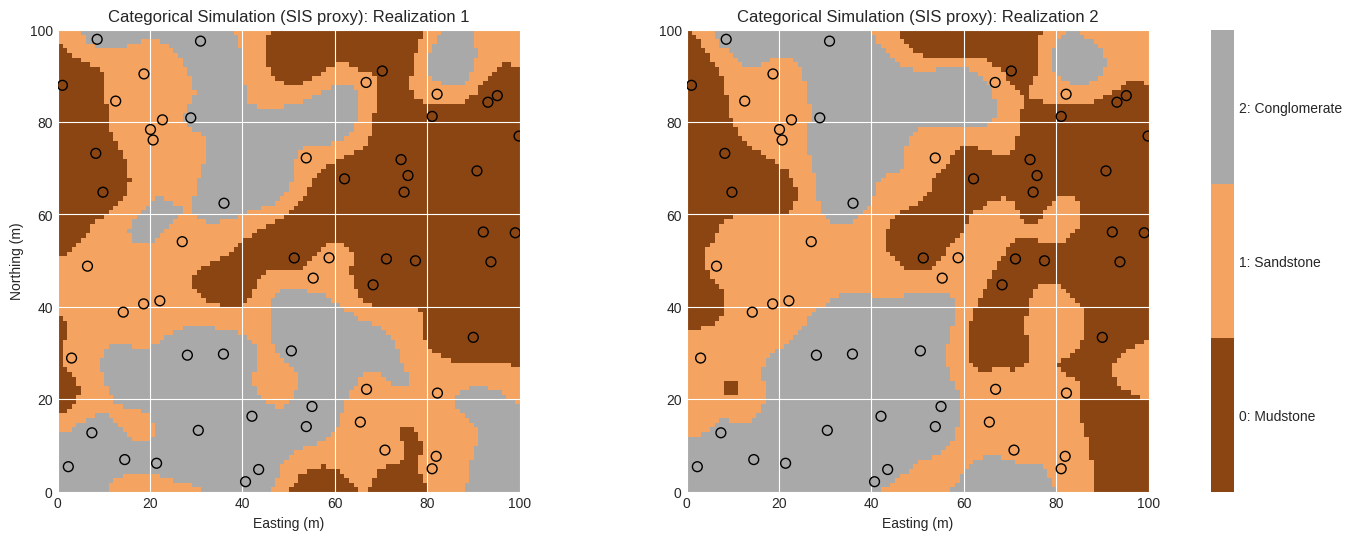

In [11]:
import matplotlib.colors as mcolors

# 1. Create synthetic categorical conditioning data
np.random.seed(303)
x_cat = np.random.uniform(0, 100, 60)
y_cat = np.random.uniform(0, 100, 60)

# Simulate 3 distinct facies based on a spatial trend to ensure grouping
# 0 = Mudstone, 1 = Sandstone, 2 = Conglomerate
z_continuous = np.sin(x_cat * 0.05) + np.cos(y_cat * 0.05) + np.random.normal(0, 0.5, 60)
z_cat = np.digitize(z_continuous, bins=[-0.5, 0.5]) # Groups into 0, 1, and 2

# 2. Define the spatial model for the simulation
# A smaller length scale makes the "patches" smaller and more disjointed
model_cat = gs.Gaussian(dim=2, var=1.0, len_scale=10)

# 3. Build the Kriging object and the Conditional SRF
# We use Simple Kriging here as it handles normalized/categorical underlying scores well
krig_cat = gs.krige.Simple(model_cat, mean=1.0, cond_pos=(x_cat, y_cat), cond_val=z_cat)
cond_srf_cat = gs.CondSRF(krig_cat)

# 4. Generate two different realizations
cond_srf_cat(pos=(gridx, gridy), mesh_type='structured', seed=555)
# Truncate the continuous realization into categories using digitize
realization_cat_1 = np.digitize(cond_srf_cat.field, bins=[0.5, 1.5])

cond_srf_cat(pos=(gridx, gridy), mesh_type='structured', seed=777)
realization_cat_2 = np.digitize(cond_srf_cat.field, bins=[0.5, 1.5])

# 5. Visualizing Categorical (Facies) Maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom discrete colormap for the 3 rock types
cmap_facies = mcolors.ListedColormap(['#8B4513', '#F4A460', '#A9A9A9']) # Brown, Sandy, Grey
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap_facies.N)

# Plot Realization 1
c1 = ax1.imshow(realization_cat_1.T, origin='lower', extent=(0, 100, 0, 100),
                cmap=cmap_facies, norm=norm)
ax1.scatter(x_cat, y_cat, c=z_cat, cmap=cmap_facies, norm=norm, edgecolors='k', s=50)
ax1.set_title('Categorical Simulation (SIS proxy): Realization 1')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')

# Plot Realization 2
c2 = ax2.imshow(realization_cat_2.T, origin='lower', extent=(0, 100, 0, 100),
                cmap=cmap_facies, norm=norm)
ax2.scatter(x_cat, y_cat, c=z_cat, cmap=cmap_facies, norm=norm, edgecolors='k', s=50)
ax2.set_title('Categorical Simulation (SIS proxy): Realization 2')
ax2.set_xlabel('Easting (m)')

# Formatting the colorbar to show category names
cbar = plt.colorbar(c2, ax=[ax1, ax2], ticks=[0, 1, 2], orientation='vertical', fraction=0.02)
cbar.ax.set_yticklabels(['0: Mudstone', '1: Sandstone', '2: Conglomerate'])

plt.show()